# 03 - EDA and Feature Engineering

**Objective:** Explore Breast Cancer data patterns and create new features.

**Steps:**
1. Statistical summary and class distribution
2. Visualizations (distributions, correlations, feature comparison by diagnosis)
3. Feature scaling
4. Feature engineering (interaction and ratio features)
5. Save engineered data

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
PROCESSED_DIR = Path("../data/processed")
CORRUPTED_DIR = PROCESSED_DIR / "corrupted"
df = pd.read_csv(PROCESSED_DIR / "clean_data.csv")
df = pd.read_csv(CORRUPTED_DIR / "corrupted_missing_heavy.csv")
print(df.info())
print(df.head())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Diagnosis               456 non-null    float64
 1   Mean_Radius             569 non-null    float64
 2   SE_Radius               569 non-null    float64
 3   Worst_Radius            569 non-null    float64
 4   Mean_Texture            569 non-null    float64
 5   SE_Texture              569 non-null    float64
 6   Worst_Texture           569 non-null    float64
 7   Mean_Perimeter          569 non-null    float64
 8   SE_Perimeter            569 non-null    float64
 9   Worst_Perimeter         569 non-null    float64
 10  Mean_Area               569 non-null    float64
 11  SE_Area                 569 non-null    float64
 12  Worst_Area              569 non-null    float64
 13  Mean_Smoothness         569 non-null    float64
 14  SE_Smoothness           569 non-null    fl

### Statistical Summary & Distribution

Before building any models, it is important to understand the range and spread of your data.
The target variable — `Diagnosis` — is binary (a classification problem).
Check the class balance to see if the dataset is imbalanced, which might affect model evaluation.

Breast cancer data has 30 features grouped into three categories:
- **Mean_** (10 features): average measurements of cell nuclei
- **SE_** (10 features): standard error of measurements
- **Worst_** (10 features): largest (worst) measurements

In [6]:
print("Class distribution (Diagnosis):")
print(df["Diagnosis"].value_counts())
print("\nFeature summary statistics:")
print(df.describe())

Class distribution (Diagnosis):
Diagnosis
0.0    286
1.0    170
Name: count, dtype: int64

Feature summary statistics:
        Diagnosis  Mean_Radius   SE_Radius  Worst_Radius  Mean_Texture  \
count  456.000000   569.000000  569.000000    569.000000    569.000000   
mean     0.372807    14.127292   19.289649     91.969033    654.889104   
std      0.484082     3.524049    4.301036     24.298981    351.914129   
min      0.000000     6.981000    9.710000     43.790000    143.500000   
25%      0.000000    11.700000   16.170000     75.170000    420.300000   
50%      0.000000    13.370000   18.840000     86.240000    551.100000   
75%      1.000000    15.780000   21.800000    104.100000    782.700000   
max      1.000000    28.110000   39.280000    188.500000   2501.000000   

       SE_Texture  Worst_Texture  Mean_Perimeter  SE_Perimeter  \
count  569.000000     569.000000      569.000000    569.000000   
mean     0.096360       0.104341        0.088799      0.048919   
std      0.01406

#### A little primer on groupby 

- `groupby` is a powerful pandas method that allows you to split your data into groups based on some criteria, apply a function to each group, and then combine the results. For example, to see how measurements differ between benign and malignant tumors, you can do:

```python
mean_by_diagnosis = df.groupby("Diagnosis")["Mean_Radius"].mean()
```

- `aggregate` is a method that allows you to apply multiple functions to your grouped data. For example, to get both the mean and standard deviation of Mean_Radius by Diagnosis, you can do:

```python
stats_by_diagnosis = df.groupby("Diagnosis")["Mean_Radius"].aggregate(["mean", "std"])
```

Aggregate functions can be any function that takes a Series and returns a single value, such as `mean`, `std`, `min`, `max`, etc.
Aggregate can be deployed on multiple columns at once, and you can specify different functions for each column if needed.

In [7]:
# === Executed Example: GroupBy and Aggregate ===
# Small inline dataset showing how groupby splits data by Diagnosis
# and compares average measurements between classes.

import pandas as pd

data = pd.DataFrame({
    "Diagnosis": [0, 0, 0, 1, 1, 1],
    "Mean_Radius": [12.0, 13.5, 11.8, 17.2, 18.5, 16.9],
    "Mean_Texture": [18.5, 20.2, 17.1, 21.4, 22.0, 20.8],
})

mean_by_diag = data.groupby("Diagnosis")["Mean_Radius"].mean()
print("Average Mean_Radius by Diagnosis:\n", mean_by_diag)

stats_by_diag = data.groupby("Diagnosis")["Mean_Texture"].agg(["mean", "std", "min", "max"])
print("\nTexture statistics by Diagnosis:\n", stats_by_diag)

Average Mean_Radius by Diagnosis:
 Diagnosis
0    12.433333
1    17.533333
Name: Mean_Radius, dtype: float64

Texture statistics by Diagnosis:
            mean       std   min   max
Diagnosis                            
0          18.6  1.552417  17.1  20.2
1          21.4  0.600000  20.8  22.0


In [8]:
# === Commented Template: GroupBy and Aggregate ===
# Uncomment and adapt to your own dataset.

# import pandas as pd
# data = pd.DataFrame({
#     "group_col": [val1, val1, val2, val2],
#     "value_col": [10, 20, 30, 40],
# })
# grouped = data.groupby("group_col")["value_col"].mean()
#     stats = data.groupby("group_col")["value_col"].agg(["mean", "std", "min", "max"])

### Missing Value Imputation

Our clean data has no missing values, but the corrupted variants from
`data_injection/` do. Common strategies:

- **Drop rows**: `df.dropna()` — fast, loses samples
- **Mean/Median imputation**: `SimpleImputer(strategy='median')` — preserves sample count
- **KNN imputation**: `KNNImputer()` — estimates from neighbors, more robust
- **Forward fill**: `df.ffill()` — for sequential data

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

# Simulate missing values on a copy
df_test = df.copy()
df_test.loc[:5, 'Mean_Radius'] = np.nan
print(f"Before: {df_test['Mean_Radius'].isna().sum()} NaNs")

imputer = SimpleImputer(strategy='mean')
imputer = KNNImputer(n_neighbors=3)
df_test['Mean_Radius'] = imputer.fit_transform(df_test[['Mean_Radius']])
print(f"After: {df_test['Mean_Radius'].isna().sum()} NaNs")
print(f"Imputed value (mean): {imputer.statistics_[0]:.3f}")

Before: 6 NaNs
After: 0 NaNs
Imputed value (mean): 14.096


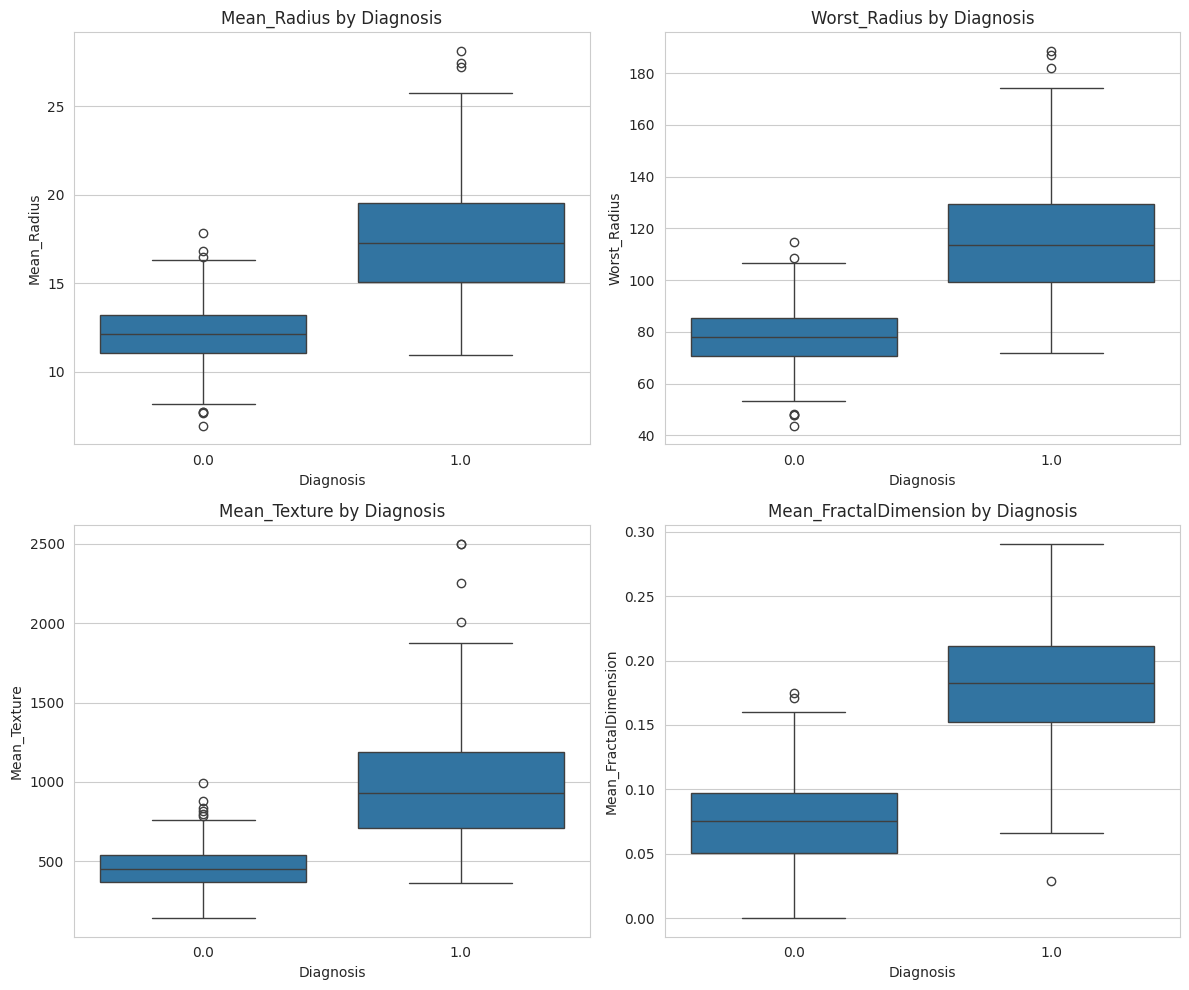

In [10]:
features_to_plot = ["Mean_Radius", "Worst_Radius", "Mean_Texture", "Mean_FractalDimension"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, feature in zip(axes.ravel(), features_to_plot):
    sns.boxplot(x="Diagnosis", y=feature, data=df, ax=ax)
    ax.set_title(f"{feature} by Diagnosis")
plt.tight_layout()
plt.show()

### Visualizations

Visual exploration helps you spot patterns and relationships that summary statistics miss.
Focus on:
- How each feature is distributed (histograms)
- How features correlate with each other and with the target (heatmap)
- Which features separate benign from malignant (boxplots)

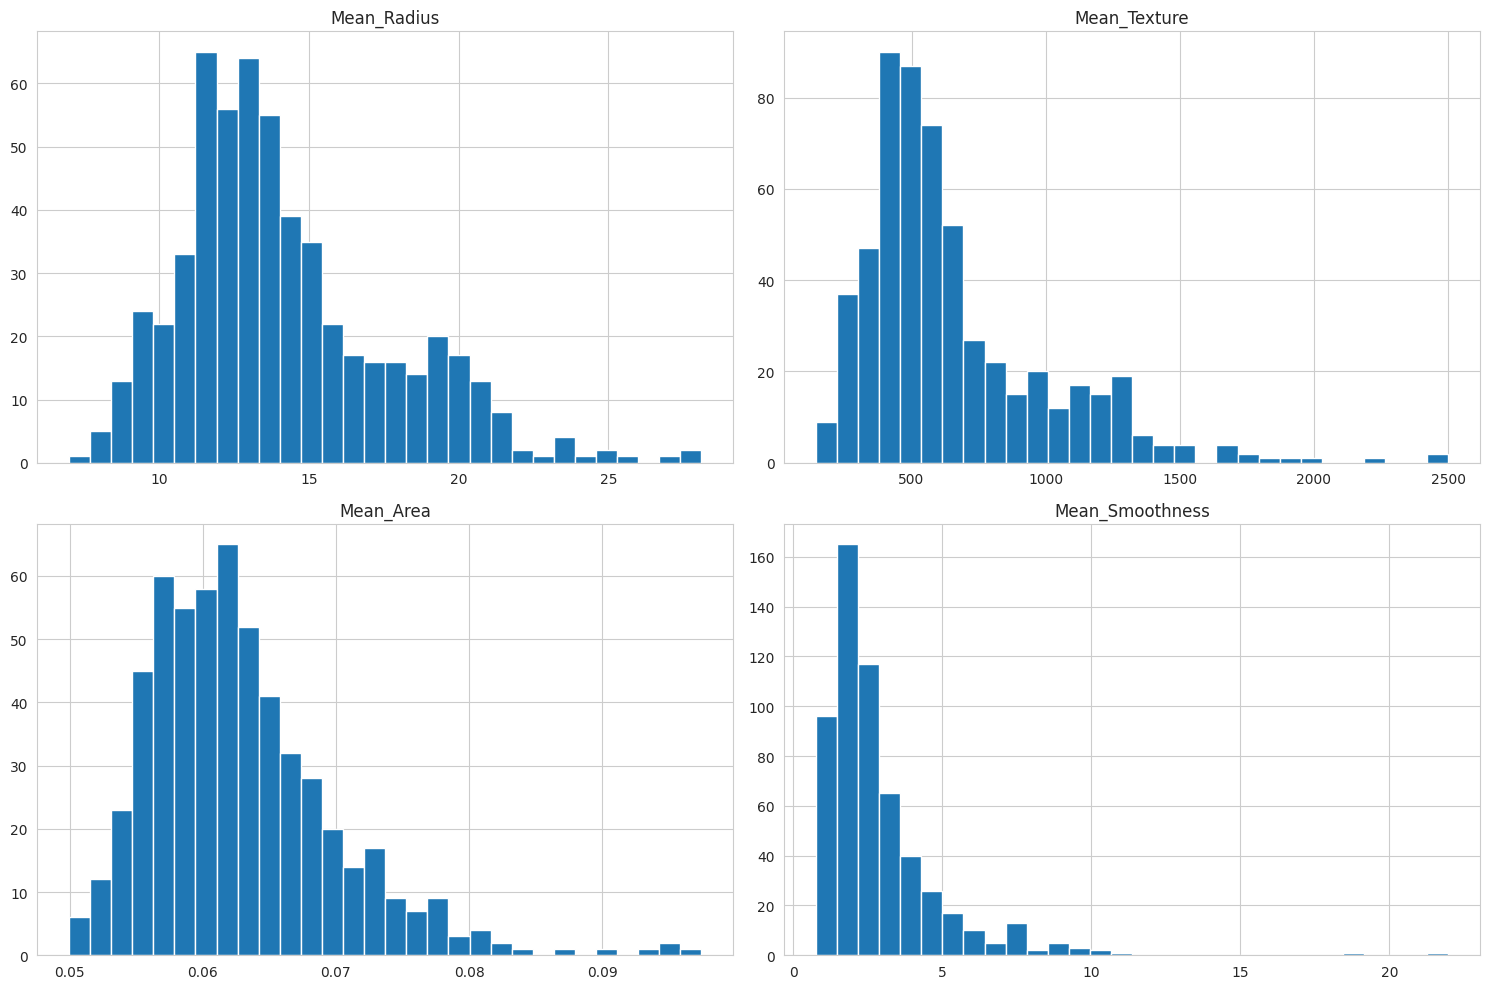

In [10]:
features_to_plot = ["Mean_Radius", "Mean_Texture", "Mean_Area", "Mean_Smoothness"]
df[features_to_plot].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

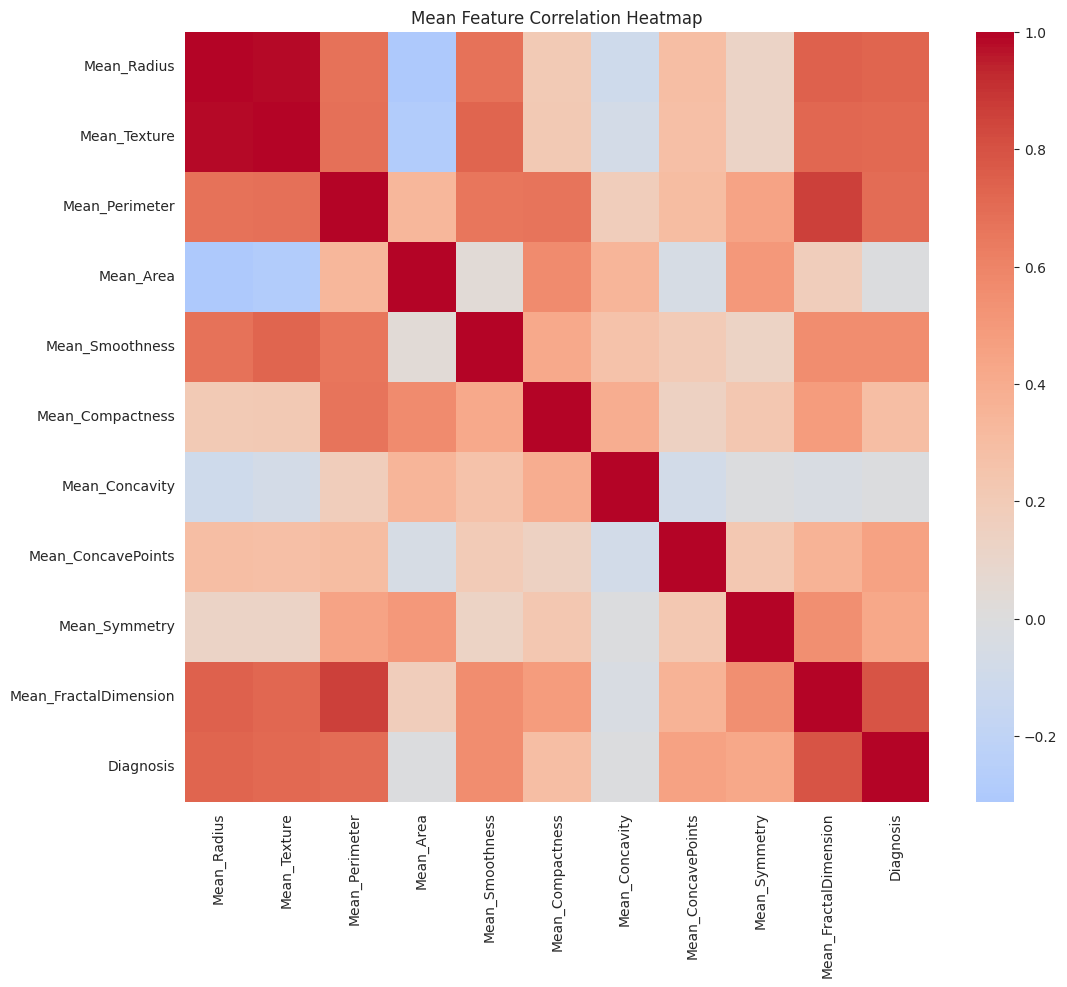

Top correlations with Diagnosis:
Diagnosis                 1.000000
Mean_FractalDimension     0.793566
SE_ConcavePoints          0.782914
SE_Perimeter              0.776614
Worst_Concavity           0.776454
Worst_Radius              0.742636
Worst_ConcavePoints       0.733825
Mean_Radius               0.730029
Mean_Texture              0.708984
Mean_Perimeter            0.696360
Worst_Symmetry            0.659610
Worst_Texture             0.596534
SE_Symmetry               0.590998
SE_Area                   0.567134
Mean_Smoothness           0.556141
SE_Smoothness             0.548236
Mean_ConcavePoints        0.456903
Mean_Symmetry             0.421465
SE_FractalDimension       0.416294
SE_Radius                 0.415185
Worst_Compactness         0.408042
SE_Texture                0.358560
Worst_Perimeter           0.330499
Worst_FractalDimension    0.323872
Mean_Compactness          0.292999
SE_Compactness            0.253730
SE_Concavity              0.077972
Mean_Concavity        

In [9]:
mean_features = [col for col in df.columns if col.startswith("Mean_")]

plt.figure(figsize=(12, 10))
sns.heatmap(df[mean_features + ["Diagnosis"]].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Mean Feature Correlation Heatmap")
plt.show()

target_corr = df.corr()["Diagnosis"].sort_values(ascending=False)
print("Top correlations with Diagnosis:")
print(target_corr)

### Feature Scaling

Many machine learning algorithms (SVR, linear models, neural networks) are sensitive to
the scale of input features. StandardScaler transforms each feature to have mean 0 and
standard deviation 1, which puts all features on equal footing.

Tree-based models (Random Forest, XGBoost) do not require scaling since they split on
thresholds independently of feature magnitude.

In [10]:
# === Executed Example: Feature Scaling ===
# Small inline dataset showing how StandardScaler transforms features
# to have mean ~0 and std ~1.

from sklearn.preprocessing import StandardScaler
import pandas as pd

data = pd.DataFrame({
    "Mean_Radius": [12.0, 13.5, 11.8, 17.2, 18.5],
    "Mean_Texture": [18.5, 20.2, 17.1, 21.4, 22.0],
    "Diagnosis": [0, 0, 0, 1, 1],
})

scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[["Mean_Radius", "Mean_Texture"]])
scaled_df = pd.DataFrame(scaled_features, columns=["Mean_Radius_scaled", "Mean_Texture_scaled"])
scaled_df["Diagnosis"] = data["Diagnosis"]
print(scaled_df)
print(f"Means after scaling: {scaled_df[['Mean_Radius_scaled', 'Mean_Texture_scaled']].mean().values}")
print(f"Stds after scaling: {scaled_df[['Mean_Radius_scaled', 'Mean_Texture_scaled']].std().values}")

   Mean_Radius_scaled  Mean_Texture_scaled  Diagnosis
0           -0.945861            -0.736931          0
1           -0.400172             0.197982          0
2           -1.018620            -1.506860          0
3            0.945861             0.857920          1
4            1.418792             1.187890          1
Means after scaling: [ 8.8817842e-17 -8.8817842e-17]
Stds after scaling: [1.11803399 1.11803399]


In [11]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Mean after scaling (first 5 features): {X_scaled.mean(axis=0)[:5]}")
print(f"Std after scaling (first 5 features): {X_scaled.std(axis=0)[:5]}")
print(f"All means near zero: {np.allclose(X_scaled.mean(axis=0), 0, atol=1e-10)}")

Mean after scaling (first 5 features): [-1.37363271e-16  6.86816353e-17 -1.24875700e-16 -2.18532476e-16
 -8.36667193e-16]
Std after scaling (first 5 features): [1. 1. 1. 1. 1.]
All means near zero: True


In [ ]:

df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
features_to_plot = ["Mean_Radius", "Mean_Texture", "Mean_Area", "Mean_Smoothness"]
df_scaled[features_to_plot].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

### Feature Engineering

New features derived from existing columns can capture interactions and non-linear relationships.
Good candidates for breast cancer:
- **Ratio features**: `Mean_Radius / Mean_Perimeter` — tumor shape compactness
- **Interaction features**: `Mean_Radius × Mean_Concave_Points` — combined malignancy indicator
- **Area ratio**: `Worst_Area / Mean_Area` — growth rate proxy

Be careful with division by zero — add a small epsilon or +1 to the denominator.

#### Note

In pandas, you can create interaction features like this:

```python
df["feature1_feature2"] = df["feature1"] * df["feature2"]
```

In [12]:
# === Executed Example: Interaction Features ===
# Multiplication and ratio on a small inline dataset.

import pandas as pd

data = pd.DataFrame({
    "Mean_Radius": [12.0, 13.5, 11.8, 17.2, 18.5],
    "Mean_Perimeter": [78.5, 85.2, 74.1, 112.4, 120.0],
    "Mean_Concave_Points": [0.05, 0.08, 0.03, 0.15, 0.18],
})

data["Radius_Perimeter_Ratio"] = data["Mean_Radius"] / data["Mean_Perimeter"]
print("Radius / Perimeter ratio:\n", data[["Mean_Radius", "Mean_Perimeter", "Radius_Perimeter_Ratio"]])

data["Radius_Concavity"] = data["Mean_Radius"] * data["Mean_Concave_Points"]
print("\nRadius × Concavity:\n", data[["Mean_Radius", "Mean_Concave_Points", "Radius_Concavity"]])

Radius / Perimeter ratio:
    Mean_Radius  Mean_Perimeter  Radius_Perimeter_Ratio
0         12.0            78.5                0.152866
1         13.5            85.2                0.158451
2         11.8            74.1                0.159244
3         17.2           112.4                0.153025
4         18.5           120.0                0.154167

Radius × Concavity:
    Mean_Radius  Mean_Concave_Points  Radius_Concavity
0         12.0                 0.05             0.600
1         13.5                 0.08             1.080
2         11.8                 0.03             0.354
3         17.2                 0.15             2.580
4         18.5                 0.18             3.330


In [13]:
# === Commented Template: Interaction Features ===
# Uncomment and adapt to your own dataset.

# import pandas as pd
# data = pd.DataFrame({
#     "feature_a": [val1, val2, val3],
#     "feature_b": [val1, val2, val3],
# })
# data["a_times_b"] = data["feature_a"] * data["feature_b"]
# EPS = 1e-6
# data["a_over_b"] = data["feature_a"] / (data["feature_b"] + EPS)

In [14]:
EPS = 1e-6
df["Radius_Perimeter_Ratio"] = df["Mean_Radius"] / (df["Mean_Perimeter"] + EPS)
df["Texture_Radius_Ratio"] = df["Mean_Texture"] / (df["Mean_Radius"] + EPS)
df["Worst_to_Mean_Area"] = df["Worst_Area"] / (df["Mean_Area"] + EPS)
df["Worst_to_Mean_Radius"] = df["Worst_Radius"] / (df["Mean_Radius"] + EPS)

print("New feature statistics:")
print(df[["Radius_Perimeter_Ratio", "Texture_Radius_Ratio", "Worst_to_Mean_Area", "Worst_to_Mean_Radius"]].describe())

New feature statistics:
       Radius_Perimeter_Ratio  Texture_Radius_Ratio  Worst_to_Mean_Area  \
count            5.690000e+02            569.000000          569.000000   
mean             2.154954e+05             43.583390           19.452995   
std              1.424949e+06             11.160170            8.744607   
min              2.368787e+01             20.555791            5.904821   
25%              1.214134e+02             35.892397           13.360835   
50%              2.111759e+02             41.175581           17.719510   
75%              4.212256e+02             49.482218           23.589452   
max              1.227000e+07             91.210792           75.770501   

       Worst_to_Mean_Radius  
count            569.000000  
mean               6.489890  
std                0.131440  
min                6.175257  
25%                6.391950  
50%                6.468895  
75%                6.562342  
max                7.120911  


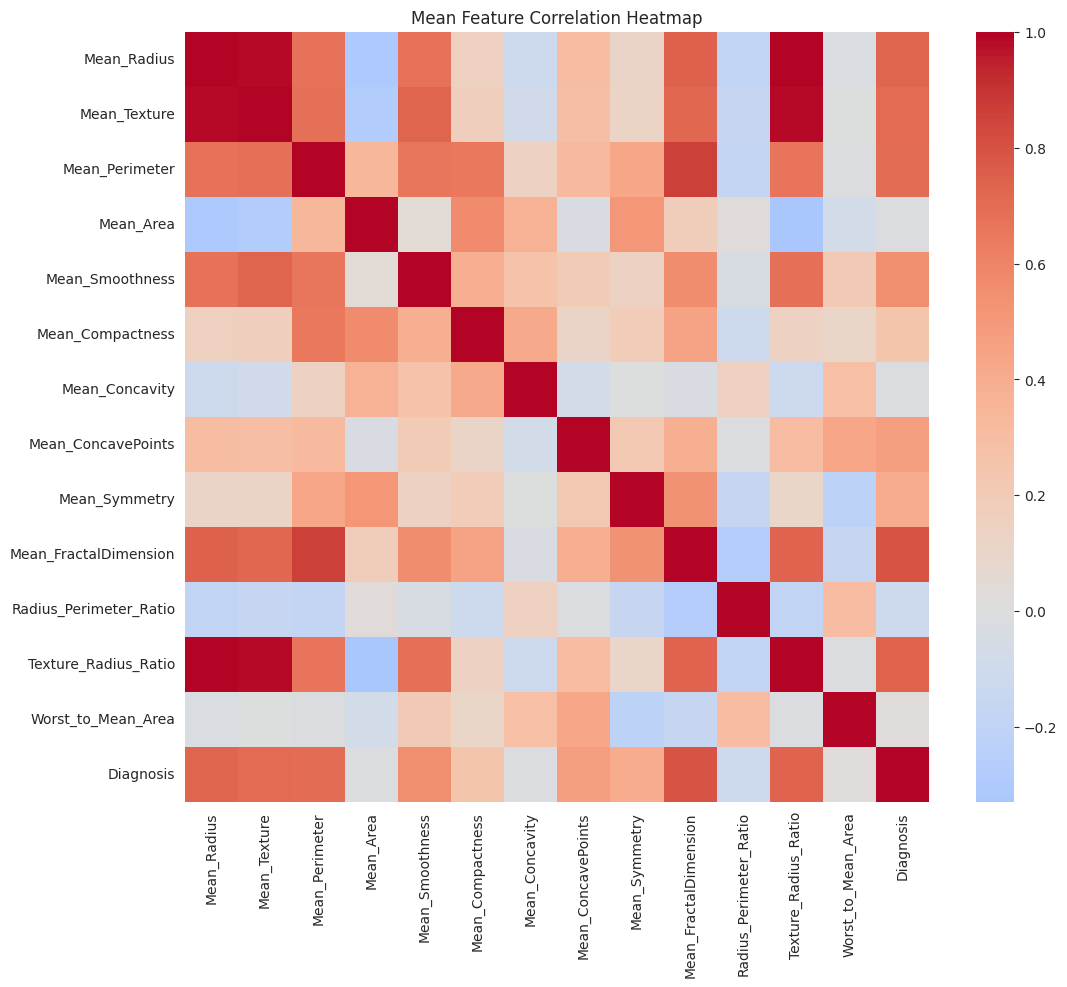

Top correlations with Diagnosis:
Diagnosis                 1.000000
Mean_FractalDimension     0.789023
SE_Perimeter              0.787339
SE_ConcavePoints          0.784429
Worst_Concavity           0.777076
Worst_Radius              0.746700
Texture_Radius_Ratio      0.735793
Mean_Radius               0.733852
Worst_ConcavePoints       0.729691
Mean_Texture              0.708654
Mean_Perimeter            0.700495
Worst_to_Mean_Radius      0.653551
Worst_Symmetry            0.651638
Worst_Texture             0.605353
SE_Symmetry               0.582465
SE_Area                   0.566882
Mean_Smoothness           0.553429
SE_Smoothness             0.540444
Mean_ConcavePoints        0.472080
Worst_Compactness         0.411477
SE_FractalDimension       0.406020
SE_Radius                 0.400518
Mean_Symmetry             0.399506
SE_Texture                0.366760
Worst_Perimeter           0.344474
Worst_FractalDimension    0.314830
SE_Compactness            0.249817
Mean_Compactness      

In [17]:
mean_features = [col for col in df.columns if col.startswith("Mean_")]

plt.figure(figsize=(12, 10))
sns.heatmap(df[mean_features + ["Radius_Perimeter_Ratio","Texture_Radius_Ratio", "Worst_to_Mean_Area","Diagnosis"]].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Mean Feature Correlation Heatmap")
plt.show()

target_corr = df.corr()["Diagnosis"].sort_values(ascending=False)
print("Top correlations with Diagnosis:")
print(target_corr)

In [28]:
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(PROCESSED_DIR / "clean_data.csv", index=False)
print("Engineered data saved to data/processed/engineered_data.csv")

Engineered data saved to data/processed/engineered_data.csv


### Unsupervised Clustering (KMeans)

Clustering groups observations without using the target labels.
We use **KMeans** which partitions data into $k$ clusters by minimizing
within-cluster variance.

**Questions:**
- Do the clusters found by KMeans align with the actual Diagnosis classes?
- How many natural groups exist in the data?


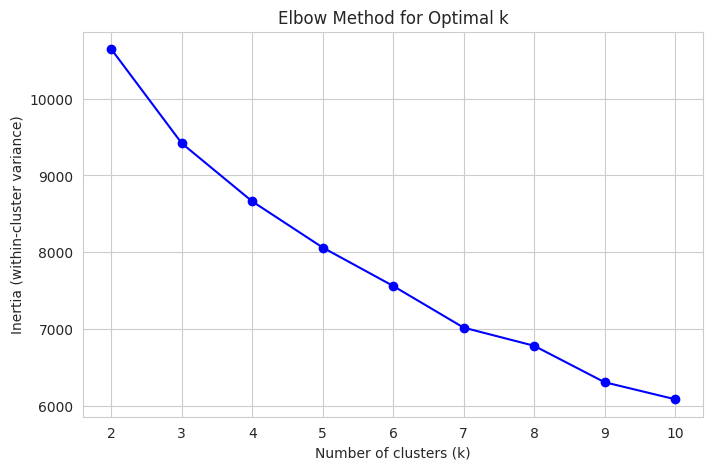

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
# Impute using KNNImputer (example, not shown here) before clustering if needed.
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(df.drop("Diagnosis", axis=1).select_dtypes(include=[np.number]))

# Scale features (clustering is distance-sensitive)
X_clust = df.drop("Diagnosis", axis=1).select_dtypes(include=[np.number])
X_clust_scaled = StandardScaler().fit_transform(X_imputed)

# Elbow method to find optimal k
inertias = []
K_range = range(2, min(11, X_clust_scaled.shape[1] + 1))
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clust_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster variance)')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.grid(True)
plt.show()


In [30]:
# Fit KMeans with the chosen k (elbow suggests k=2 for binary classification)
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_clust_scaled)

# Compare cluster labels vs actual target
from sklearn.metrics import adjusted_rand_score
df.dropna(subset=["Diagnosis", "Cluster"], inplace=True)  # Ensure no NaNs for ARI calculation
ari = adjusted_rand_score(df["Diagnosis"], df["Cluster"])
print(f"Adjusted Rand Index (cluster vs Diagnosis): {ari:.4f}")
print("\nContingency table (cluster x target):")
print(pd.crosstab(df["Cluster"], df["Diagnosis"], rownames=["Cluster"], colnames=["Diagnosis"]))


Adjusted Rand Index (cluster vs Diagnosis): 0.6917

Contingency table (cluster x target):
Diagnosis  0.0  1.0
Cluster            
0           10  142
1          276   28


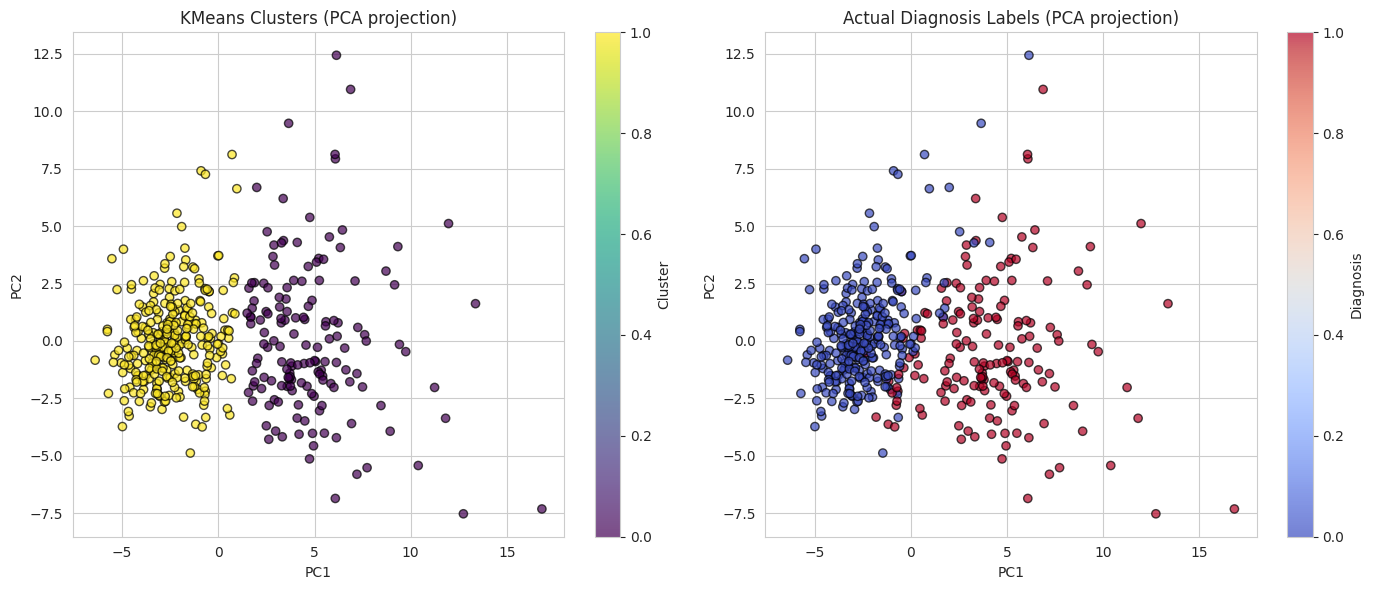

In [31]:
# Visualize clusters via PCA projection
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X_clust_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = ax1.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=df["Cluster"], cmap="viridis", edgecolors="k", alpha=0.7)
ax1.set_title("KMeans Clusters (PCA projection)")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
plt.colorbar(scatter1, ax=ax1, label="Cluster")

scatter2 = ax2.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=df["Diagnosis"], cmap="coolwarm", edgecolors="k", alpha=0.7)
ax2.set_title("Actual Diagnosis Labels (PCA projection)")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
plt.colorbar(scatter2, ax=ax2, label="Diagnosis")

plt.tight_layout()
plt.show()


### Principal Component Analysis (PCA)

PCA finds orthogonal axes (principal components) that capture the maximum variance
in the data. It is useful for:
- **Dimensionality reduction**: compressing many features into fewer components
- **Visualization**: projecting high-dimensional data to 2D or 3D
- **Noise reduction**: discarding low-variance components

PCA is **unsupervised** — it does not use the target labels.


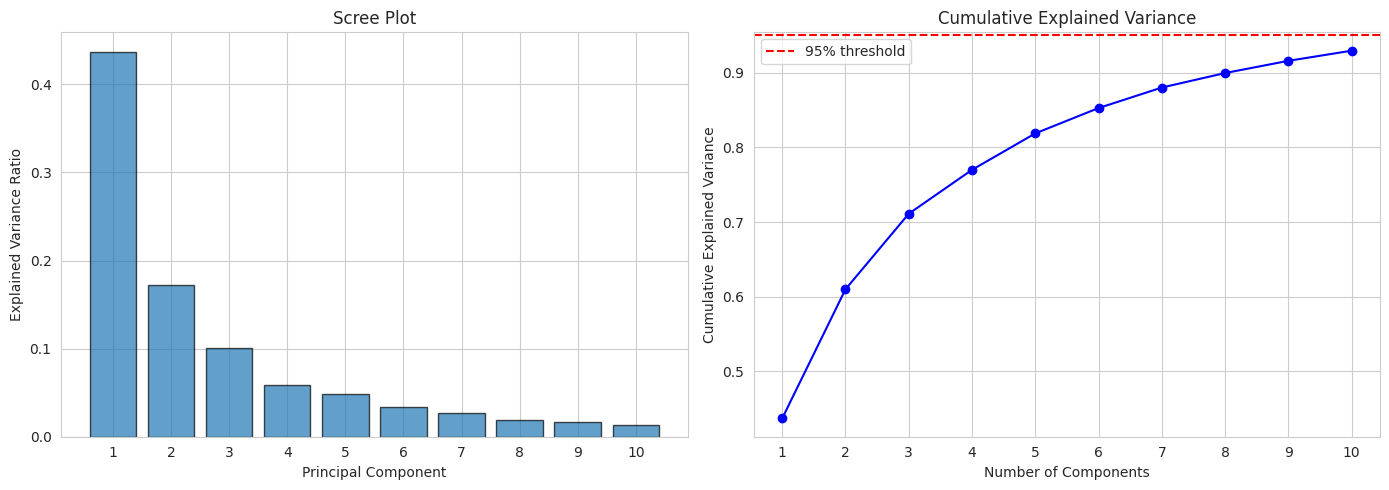

First 2 components explain 61.0% of variance
First 3 components explain 71.1% of variance


In [57]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df.drop("Diagnosis", axis=1).select_dtypes(include=[np.number])
if "Cluster" in X.columns:
    X = X.drop("Cluster", axis=1)


imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(df.drop("Diagnosis", axis=1).select_dtypes(include=[np.number]))

X_scaled = StandardScaler().fit_transform(X_imputed)

# Fit PCA with many components
n_comps = min(X.shape[1], 10)
pca = PCA(n_components=n_comps, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, n_comps + 1), pca.explained_variance_ratio_, alpha=0.7, edgecolor="k")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")
axes[0].set_xticks(range(1, n_comps + 1))

cumulative = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, n_comps + 1), cumulative, "bo-")
axes[1].axhline(y=0.95, color="r", linestyle="--", label="95% threshold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()
axes[1].set_xticks(range(1, n_comps + 1))
plt.tight_layout()
plt.show()

print(f"First 2 components explain {pca.explained_variance_ratio_[:2].sum():.1%} of variance")
print(f"First 3 components explain {pca.explained_variance_ratio_[:3].sum():.1%} of variance")


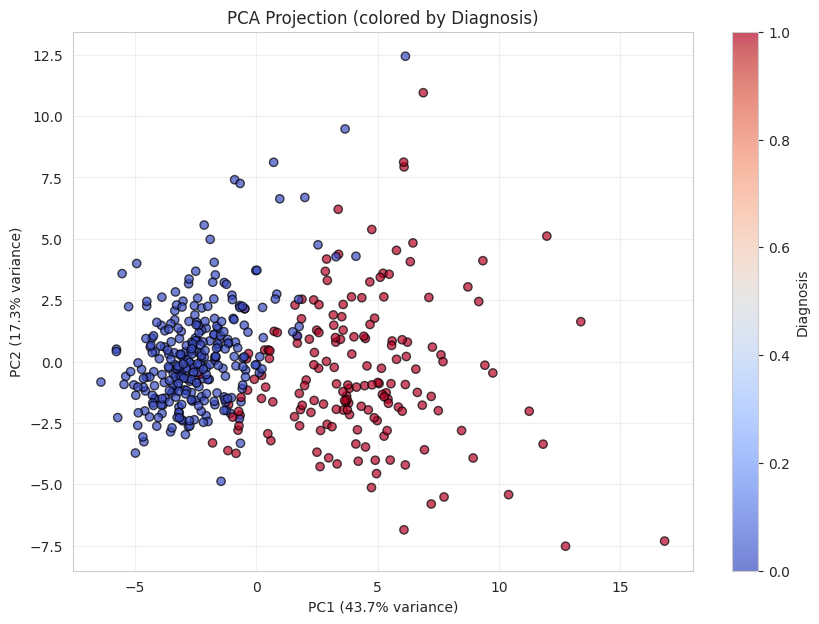

In [51]:
# 2D PCA projection colored by target
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Diagnosis"], cmap="coolwarm", edgecolors="k", alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA Projection (colored by Diagnosis)")
plt.colorbar(scatter, label="Diagnosis")
plt.grid(True, alpha=0.3)
plt.show()


Top 5 contributors to PC1:
SE_Perimeter             0.243924
Mean_Perimeter           0.237782
Mean_FractalDimension    0.234107
SE_ConcavePoints         0.225435
Worst_to_Mean_Radius     0.225294
Name: PC1, dtype: float64


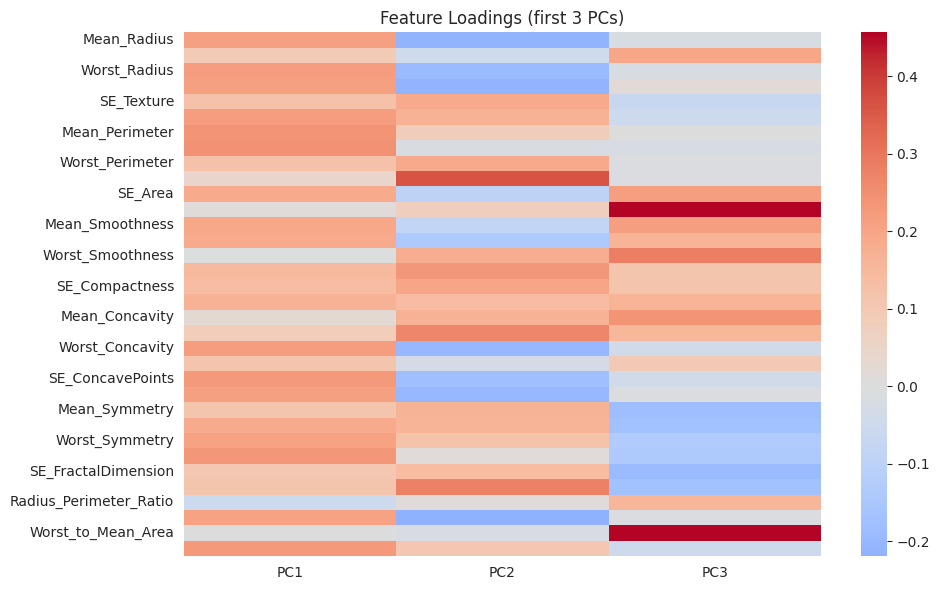

In [60]:
# Feature loadings — contribution of each original feature to PCs
loadings = pd.DataFrame(
    pca.components_.T[:-1, :3],
    index=X.columns,
    columns=["PC1", "PC2", "PC3"],
)

print("Top 5 contributors to PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=False, cmap="coolwarm", center=0)
plt.title("Feature Loadings (first 3 PCs)")
plt.tight_layout()
plt.show()


### Linear Discriminant Analysis (LDA)

LDA finds axes that **maximize class separability**. Unlike PCA (unsupervised),
LDA uses the target labels to find projections that best separate the classes.

**LDA vs PCA**:
- PCA maximizes **variance** (ignores labels)
- LDA maximizes **class separation** (uses labels)
- For classification, LDA often gives better separation in fewer components


In [40]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler

X = df.drop("Diagnosis", axis=1).select_dtypes(include=[np.number])
if "Cluster" in X.columns:
    X = X.drop("Cluster", axis=1)
X_scaled = StandardScaler().fit_transform(X)
X_imputed = KNNImputer(n_neighbors=5).fit_transform(X_scaled)
y = df["Diagnosis"]

n_classes = y.nunique()
n_lda_comps = min(n_classes - 1, X_imputed.shape[1])
lda = LDA(n_components=n_lda_comps)
X_lda = lda.fit_transform(X_imputed, y)

print(f"LDA reduced {X_scaled.shape[1]} features to {X_lda.shape[1]} component(s)")


LDA reduced 34 features to 1 component(s)


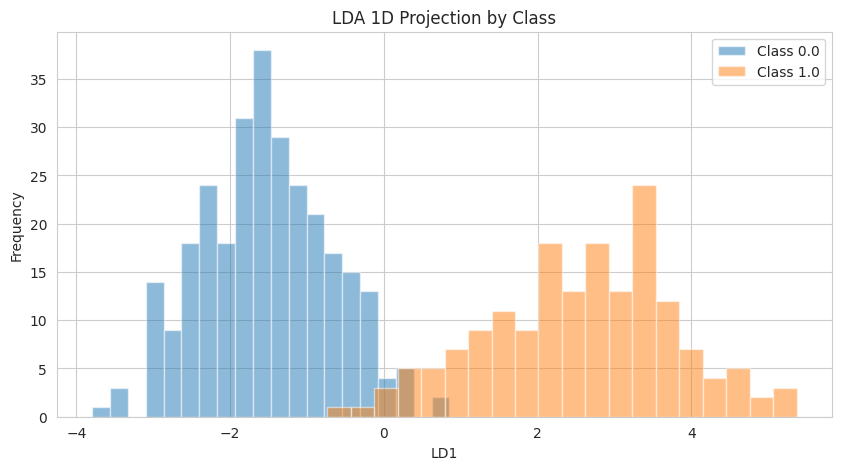

In [41]:
# Visualize LDA projection
if X_lda.shape[1] >= 2:
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap="coolwarm", edgecolors="k", alpha=0.7)
    plt.xlabel("LD1")
    plt.ylabel("LD2")
    plt.title("LDA Projection (colored by Diagnosis)")
    plt.colorbar(scatter, label="Diagnosis")
    plt.grid(True, alpha=0.3)
else:
    plt.figure(figsize=(10, 5))
    for cls in sorted(y.unique()):
        plt.hist(X_lda[y == cls, 0], bins=20, alpha=0.5, label=f"Class {cls}")
    plt.xlabel("LD1")
    plt.ylabel("Frequency")
    plt.title("LDA 1D Projection by Class")
    plt.legend()
plt.show()


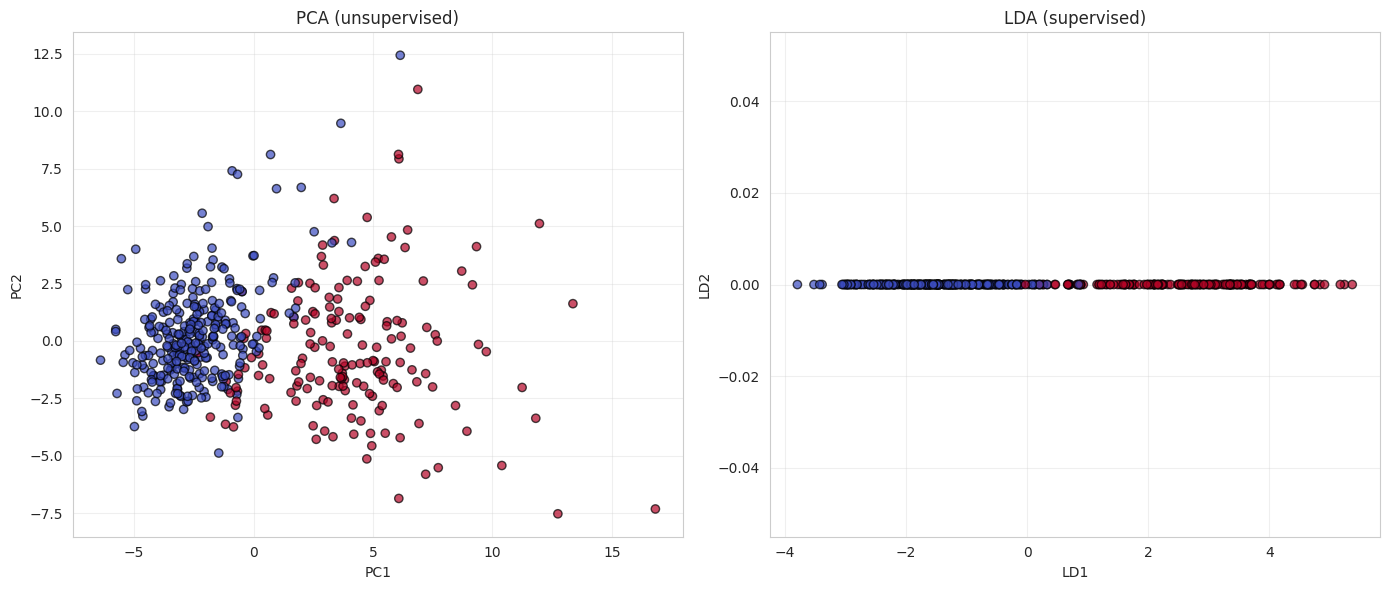

In [42]:
# Side-by-side: PCA vs LDA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# PCA (first 2 components)
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", edgecolors="k", alpha=0.7)
ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2")
ax1.set_title("PCA (unsupervised)")
ax1.grid(True, alpha=0.3)

# LDA
x_lda_2d = X_lda[:, :min(2, X_lda.shape[1])]
if x_lda_2d.shape[1] == 1:
    x_lda_2d = np.hstack([x_lda_2d, np.zeros_like(x_lda_2d)])
scatter2 = ax2.scatter(x_lda_2d[:, 0], x_lda_2d[:, 1], c=y, cmap="coolwarm", edgecolors="k", alpha=0.7)
ax2.set_xlabel("LD1")
ylabel = "LD2" if x_lda_2d.shape[1] > 1 else "(none)"
ax2.set_ylabel(ylabel)
ax2.set_title("LDA (supervised)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Recursive Feature Elimination (RFE)

RFE recursively removes the least important features, building a model at each step.
It ranks features by importance and finds the optimal subset.

**Benefits:**
- Reduces overfitting by removing noisy features
- Improves model interpretability
- Can speed up training and prediction


In [44]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LogisticRegression

X = df.drop("Diagnosis", axis=1).select_dtypes(include=[np.number])
if "Cluster" in X.columns:
    X = X.drop("Cluster", axis=1)

X_scaled = StandardScaler().fit_transform(X)
X_imputed = KNNImputer(n_neighbors=5).fit_transform(X_scaled)

y = df["Diagnosis"]

estimator = LogisticRegression(max_iter=1000, random_state=42)

# RFE with a fixed number of features
rfe = RFE(estimator=estimator, n_features_to_select=min(10, X_scaled.shape[1]), step=1)
rfe.fit(X_imputed, y)

print("Feature Ranking (1 = selected, higher = less important):")
ranking_df = pd.DataFrame({
    "Feature": X.columns,
    "Rank": rfe.ranking_,
    "Selected": rfe.support_,
}).sort_values("Rank")
print(ranking_df)


Feature Ranking (1 = selected, higher = less important):
                   Feature  Rank  Selected
7             SE_Perimeter     1      True
10                 SE_Area     1      True
13           SE_Smoothness     1      True
27   Mean_FractalDimension     1      True
20         Worst_Concavity     1      True
21      Mean_ConcavePoints     1      True
22        SE_ConcavePoints     1      True
23     Worst_ConcavePoints     1      True
31    Texture_Radius_Ratio     1      True
24           Mean_Symmetry     1      True
26          Worst_Symmetry     2     False
15        Mean_Compactness     3     False
1                SE_Radius     4     False
3             Mean_Texture     5     False
12         Mean_Smoothness     6     False
6           Mean_Perimeter     7     False
28     SE_FractalDimension     8     False
19            SE_Concavity     9     False
18          Mean_Concavity    10     False
14        Worst_Smoothness    11     False
9                Mean_Area    12     Fal

Optimal number of features: 30


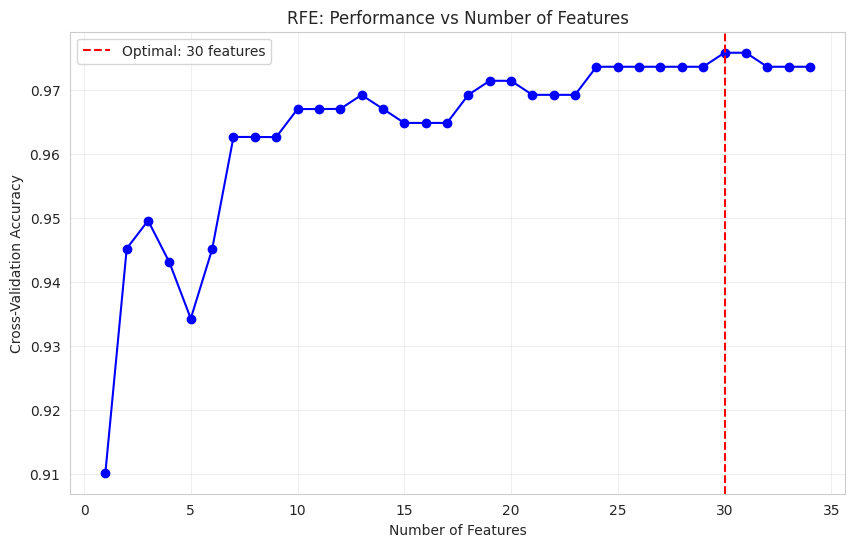

In [46]:
# RFECV: automatically determine optimal number of features
rfecv = RFECV(estimator=estimator, step=1, cv=5, scoring='accuracy', min_features_to_select=1)
rfecv.fit(X_imputed, y)

print(f"Optimal number of features: {rfecv.n_features_}")

# Plot performance vs number of features
plt.figure(figsize=(10, 6))
n_scores = len(rfecv.cv_results_['mean_test_score'])
plt.plot(range(1, n_scores + 1),
     rfecv.cv_results_['mean_test_score'], 'bo-')
plt.axvline(x=rfecv.n_features_, color="r", linestyle="--",
           label=f"Optimal: {rfecv.n_features_} features")
plt.xlabel("Number of Features")
plt.ylabel("Cross-Validation Accuracy")
plt.title("RFE: Performance vs Number of Features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [47]:
# Selected features summary
selected_features = X.columns[rfecv.support_]
removed_features = X.columns[~rfecv.support_]
print(f"Selected features ({len(selected_features)}):")
print(list(selected_features))
print(f"\nRemoved features ({len(removed_features)}):")
print(list(removed_features))


Selected features (30):
['Mean_Radius', 'SE_Radius', 'Worst_Radius', 'Mean_Texture', 'SE_Texture', 'Worst_Texture', 'Mean_Perimeter', 'SE_Perimeter', 'Mean_Area', 'SE_Area', 'Worst_Area', 'Mean_Smoothness', 'SE_Smoothness', 'Worst_Smoothness', 'Mean_Compactness', 'SE_Compactness', 'Mean_Concavity', 'SE_Concavity', 'Worst_Concavity', 'Mean_ConcavePoints', 'SE_ConcavePoints', 'Worst_ConcavePoints', 'Mean_Symmetry', 'SE_Symmetry', 'Worst_Symmetry', 'Mean_FractalDimension', 'SE_FractalDimension', 'Worst_FractalDimension', 'Texture_Radius_Ratio', 'Worst_to_Mean_Radius']

Removed features (4):
['Worst_Perimeter', 'Worst_Compactness', 'Radius_Perimeter_Ratio', 'Worst_to_Mean_Area']


### Exercises

1. **Try different scalers**: Replace `StandardScaler` with `MinMaxScaler` or `RobustScaler` and compare how the scaled distributions look.
2. **Identify redundant features**: Find pairs of features with correlation > 0.95. Would dropping one affect model performance?
3. **Create a mean-to-se ratio**: For each Mean_ feature, create a corresponding `Mean_to_SE` ratio (e.g., `df["Radius_Mean_to_SE"] = df["Mean_Radius"] / (df["Radius_SE"] + 1e-6)`). Does this capture measurement reliability?
4. **Log transform skewed features**: Some features like `Area` may be right-skewed. Try `np.log1p()` and check if the distribution becomes more normal.
5. **Pairplot**: Use `sns.pairplot()` on a subset of the most discriminative features, coloring by Diagnosis — do benign and malignant samples form distinct clusters?